In [1]:
import time
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from concrete.ml.sklearn import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report

# Small Random Dataset - 100 samples

Make classification samples and perform train and test split

In [2]:
sd_x, sd_y = make_classification(n_samples=100, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", sd_x.min())
print("X Maximum: ", sd_x.max())

sd_x_train, sd_x_test, sd_y_train, sd_y_test = train_test_split(sd_x, sd_y, test_size=0.1, random_state=42)

X Minimum:  -3.8192253511146537
X Maximum:  3.625093656245981


Evaluate number of training and testing samples from train/test split

In [3]:
num_sd_x_training = len(sd_x_train)
num_sd_x_test = len(sd_x_test)
num_sd_y_training = len(sd_y_train)
num_sd_y_test = len(sd_y_test)

print("Number of x training: ", num_sd_x_training)
print("Number of x test: ", num_sd_x_test)
print("Number of y training: ", num_sd_y_training)
print("Number of y test: ", num_sd_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [4]:
print("sd_x_train shape: ", sd_x_train.shape)
print("sd_x_test shape: ", sd_x_test.shape)
print("sd_y_train shape: ", sd_y_train.shape)
print("sd_y_test shape: ", sd_y_train.shape) 

sd_x_train shape:  (90, 30)
sd_x_test shape:  (10, 30)
sd_y_train shape:  (90,)
sd_y_test shape:  (90,)


Initialise Model and Perform Fitting and Prediction

In [5]:
sd_total_start_time = time.time()

sd_model = LogisticRegression(n_bits=8)

sd_ml_start_time = time.time()

sd_model.fit(sd_x_train, sd_y_train)
sd_y_pred_clear = sd_model.predict(sd_x_test)
sd_model.compile(sd_x_train)

sd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmp6iykefvu/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [6]:
sd_clear_accuracy = accuracy_score(sd_y_test, sd_y_pred_clear)
sd_clear_precision = precision_score(sd_y_test, sd_y_pred_clear)
sd_clear_recall = recall_score (sd_y_test, sd_y_pred_clear)
sd_clear_f1 = f1_score(sd_y_test, sd_y_pred_clear)
sd_clear_auc = roc_auc_score(sd_y_test, sd_y_pred_clear)
sd_ml_elapsed_time = sd_ml_end_time - sd_ml_start_time

print("Cleartext Accuracy Score: ", sd_clear_accuracy)
print("Cleartext Precision Score: ", sd_clear_precision)
print("Cleartext Recall Score: ", sd_clear_recall)
print("Cleartext F1 Score: ", sd_clear_f1)
print("Cleartext AUC Score: ", sd_clear_auc)
print(f"Time it took for ML to make predictions: {sd_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  1.0
Cleartext Precision Score:  1.0
Cleartext Recall Score:  1.0
Cleartext F1 Score:  1.0
Cleartext AUC Score:  1.0
Time it took for ML to make predictions: 0.19875 seconds


Confusion Matrix - Cleartext

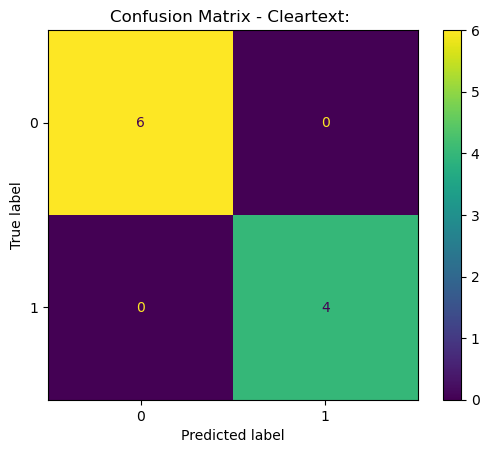

In [7]:
sd_clear_cm = metrics.confusion_matrix(sd_y_test, sd_y_pred_clear)
sd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=sd_clear_cm)
sd_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [8]:
print("Classification Report - Cleartext: ")
print(classification_report(sd_y_test, sd_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



FHE Execution and Evaluation

In [9]:
sd_fhe_prediction_start_time = time.time()

sd_y_pred_fhe = sd_model.predict(sd_x_test, fhe="execute")

sd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [10]:
sd_fhe_accuracy = accuracy_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_precision = precision_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_recall = recall_score (sd_y_test, sd_y_pred_fhe)
sd_fhe_f1 = f1_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_auc = roc_auc_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_prediction_elapsed_time = sd_fhe_prediction_end_time - sd_fhe_prediction_start_time

print("FHE Accuracy Score: ", sd_fhe_accuracy)
print("FHE Precision Score: ", sd_fhe_precision)
print("FHE Recall Score: ", sd_fhe_recall)
print("FHE F1 Score: ", sd_fhe_f1)
print("FHE AUC Score: ", sd_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {sd_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  1.0
FHE Precision Score:  1.0
FHE Recall Score:  1.0
FHE F1 Score:  1.0
FHE AUC Score:  1.0
Total time for FHE Execution and Evaluation: 0.55023 seconds


Confusion Matrix - FHE

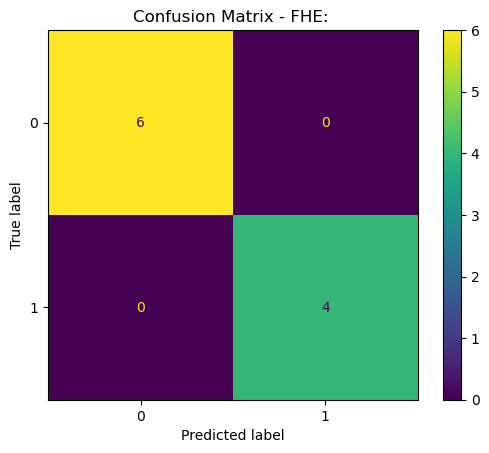

In [11]:
sd_fhe_cm = metrics.confusion_matrix(sd_y_test, sd_y_pred_fhe)
sd_fhe_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=sd_fhe_cm)
sd_fhe_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [12]:
print("Classification Report - FHE: ")
print(classification_report(sd_y_test, sd_y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Evaluation of SD Model

In [13]:
print("In clear  :", sd_y_pred_clear)
print("In FHE    :", sd_y_pred_fhe)
print(f"Similarity: {int((sd_y_pred_fhe == sd_y_pred_clear).mean()*100)}%")

sd_total_end_time = time.time()
sd_total_elapsed_time = sd_total_end_time - sd_total_start_time
print(f"Total time for SD to Run: {sd_total_elapsed_time:.5f} seconds")

In clear  : [0 0 0 0 1 0 1 0 1 1]
In FHE    : [0 0 0 0 1 0 1 0 1 1]
Similarity: 100%
Total time for SD to Run: 1.03923 seconds


# Medium Random Dataset - 1000 samples

Make classification samples and perform train and test split

In [14]:
md_x, md_y = make_classification(n_samples=1000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", md_x.min())
print("X Maximum: ", md_x.max())

md_x_train, md_x_test, md_y_train, md_y_test = train_test_split(md_x, md_y, test_size=0.1, random_state=42)

X Minimum:  -5.543441462057407
X Maximum:  5.020261576429226


Evaluate number of training and testing samples from train/test split

In [15]:
num_md_x_training = len(md_x_train)
num_md_x_test = len(md_x_test)
num_md_y_training = len(md_y_train)
num_md_y_test = len(md_y_test)

print("Number of x training: ", num_md_x_training)
print("Number of x test: ", num_md_x_test)
print("Number of y training: ", num_md_y_training)
print("Number of y test: ", num_md_y_test)

Number of x training:  900
Number of x test:  100
Number of y training:  900
Number of y test:  100


In [16]:
print("md_x_train shape: ", md_x_train.shape)
print("md_x_test shape: ", md_x_test.shape)
print("md_y_train shape: ", md_y_train.shape)
print("md_y_test shape: ", md_y_train.shape) 

md_x_train shape:  (900, 30)
md_x_test shape:  (100, 30)
md_y_train shape:  (900,)
md_y_test shape:  (900,)


Initialise Model and Perform Fitting and Prediction

In [17]:
md_total_start_time = time.time()

md_model = LogisticRegression(n_bits=8)
md_ml_start_time = time.time()

md_model.fit(md_x_train, md_y_train)
md_y_pred_clear = md_model.predict(md_x_test)
md_model.compile(md_x_train)

md_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpuk6f1wsl/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [18]:
md_clear_accuracy = accuracy_score(md_y_test, md_y_pred_clear)
md_clear_precision = precision_score(md_y_test, md_y_pred_clear)
md_clear_recall = recall_score (md_y_test, md_y_pred_clear)
md_clear_f1 = f1_score(md_y_test, md_y_pred_clear)
md_clear_auc = roc_auc_score(md_y_test, md_y_pred_clear)
md_ml_elapsed_time = md_ml_end_time - md_ml_start_time

print("Cleartext Accuracy Score: ", md_clear_accuracy)
print("Cleartext Precision Score: ", md_clear_precision)
print("Cleartext Recall Score: ", md_clear_recall)
print("Cleartext F1 Score: ", md_clear_f1)
print("Cleartext AUC Score: ", md_clear_auc)
print(f"Time it took for ML to make predictions: {md_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.97
Cleartext Precision Score:  1.0
Cleartext Recall Score:  0.9375
Cleartext F1 Score:  0.967741935483871
Cleartext AUC Score:  0.96875
Time it took for ML to make predictions: 0.37046 seconds


Confusion Matrix - Cleartext

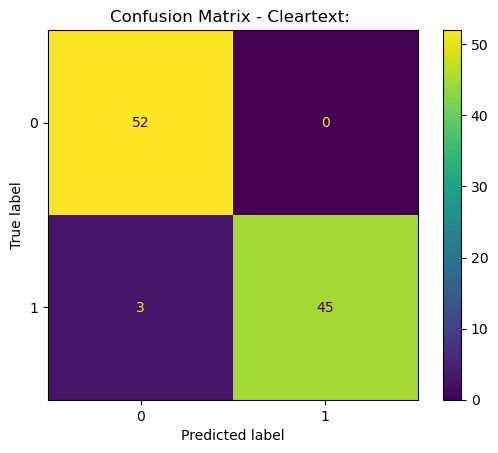

In [19]:
md_clear_cm = metrics.confusion_matrix(md_y_test, md_y_pred_clear)
md_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=md_clear_cm)
md_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [20]:
print("Classification Report - Cleartext: ")
print(classification_report(md_y_test, md_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        52
           1       1.00      0.94      0.97        48

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



FHE Execution and Evaluation

In [21]:
md_fhe_prediction_start_time = time.time()

md_y_pred_fhe = md_model.predict(md_x_test, fhe="execute")

md_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [22]:
md_fhe_accuracy = accuracy_score(md_y_test, md_y_pred_fhe)
md_fhe_precision = precision_score(md_y_test, md_y_pred_fhe)
md_fhe_recall = recall_score (md_y_test, md_y_pred_fhe)
md_fhe_f1 = f1_score(md_y_test, md_y_pred_fhe)
md_fhe_auc = roc_auc_score(md_y_test, md_y_pred_fhe)
md_fhe_prediction_elapsed_time = md_fhe_prediction_end_time - md_fhe_prediction_start_time

print("FHE Accuracy Score: ", md_fhe_accuracy)
print("FHE Precision Score: ", md_fhe_precision)
print("FHE Recall Score: ", md_fhe_recall)
print("FHE F1 Score: ", md_fhe_f1)
print("FHE AUC Score: ", md_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {md_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.97
FHE Precision Score:  1.0
FHE Recall Score:  0.9375
FHE F1 Score:  0.967741935483871
FHE AUC Score:  0.96875
Total time for FHE Execution and Evaluation: 2.04496 seconds


Confusion Matrix - FHE

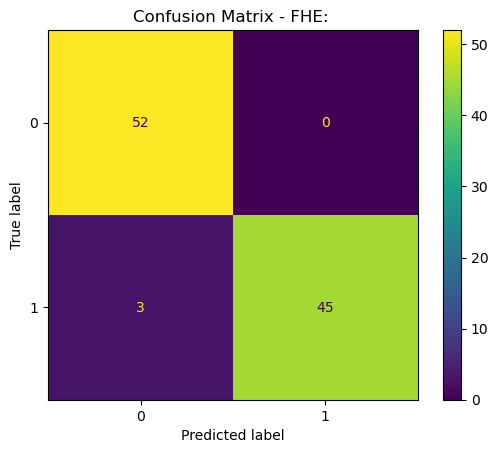

In [23]:
md_fhe_cm = metrics.confusion_matrix(md_y_test, md_y_pred_fhe)
md_fhe_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=md_fhe_cm)
md_fhe_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [24]:
print("Classification Report - FHE: ")
print(classification_report(md_y_test, md_y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        52
           1       1.00      0.94      0.97        48

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



Evaluation of MD Model

In [25]:
print("In clear  :", md_y_pred_clear)
print("In FHE    :", md_y_pred_fhe)
print(f"Similarity: {int((md_y_pred_fhe == md_y_pred_clear).mean()*100)}%")

md_total_end_time = time.time()
md_total_elapsed_time = md_total_end_time - md_total_start_time
print(f"Total time for MD to Run: {md_total_elapsed_time:.5f} seconds")

In clear  : [0 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 0
 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0]
In FHE    : [0 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 0
 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0]
Similarity: 100%
Total time for MD to Run: 2.61115 seconds


# Large Random Dataset - 10,000 samples

Make Samples and Perform Train and Test Split

In [26]:
ld_x, ld_y = make_classification(n_samples=10000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", ld_x.min())
print("X Maximum: ", ld_x.max())

ld_x_train, ld_x_test, ld_y_train, ld_y_test = train_test_split(ld_x, ld_y, test_size=0.1, random_state=42)

X Minimum:  -6.049090666105036
X Maximum:  6.765510169350037


Evaluate number of training and testing samples from train/test split

In [27]:
num_ld_x_training = len(ld_x_train)
num_ld_x_test = len(ld_x_test)
num_ld_y_training = len(ld_y_train)
num_ld_y_test = len(ld_y_test)

print("Number of x training: ", num_ld_x_training)
print("Number of x test: ", num_ld_x_test)
print("Number of y training: ", num_ld_y_training)
print("Number of y test: ", num_ld_y_test)

Number of x training:  9000
Number of x test:  1000
Number of y training:  9000
Number of y test:  1000


In [28]:
print("ld_x_train shape: ", ld_x_train.shape)
print("ld_x_test shape: ", ld_x_test.shape)
print("ld_y_train shape: ", ld_y_train.shape)
print("ld_y_test shape: ", ld_y_train.shape) 

ld_x_train shape:  (9000, 30)
ld_x_test shape:  (1000, 30)
ld_y_train shape:  (9000,)
ld_y_test shape:  (9000,)


Initialise Model and Perform Fitting and Prediction

In [29]:
ld_total_start_time = time.time()

ld_model = LogisticRegression(n_bits=8)
ld_ml_start_time = time.time()

ld_model.fit(ld_x_train, ld_y_train)
ld_y_pred_clear = ld_model.predict(ld_x_test)
ld_model.compile(ld_x_train)

ld_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmp60xo_xxp/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [30]:
ld_clear_accuracy = accuracy_score(ld_y_test, ld_y_pred_clear)
ld_clear_precision = precision_score(ld_y_test, ld_y_pred_clear)
ld_clear_recall = recall_score (ld_y_test, ld_y_pred_clear)
ld_clear_f1 = f1_score(ld_y_test, ld_y_pred_clear)
ld_clear_auc = roc_auc_score(ld_y_test, ld_y_pred_clear)
ld_ml_elapsed_time = ld_ml_end_time - ld_ml_start_time

print("Cleartext Accuracy Score: ", ld_clear_accuracy)
print("Cleartext Precision Score: ", ld_clear_precision)
print("Cleartext Recall Score: ", ld_clear_recall)
print("Cleartext F1 Score: ", ld_clear_f1)
print("Cleartext AUC Score: ", ld_clear_auc)
print(f"Time it took for ML to make predictions: {ld_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.98
Cleartext Precision Score:  0.9794661190965093
Cleartext Recall Score:  0.9794661190965093
Cleartext F1 Score:  0.9794661190965093
Cleartext AUC Score:  0.9799864708542975
Time it took for ML to make predictions: 1.49190 seconds


Confusion Matrix - Cleartext

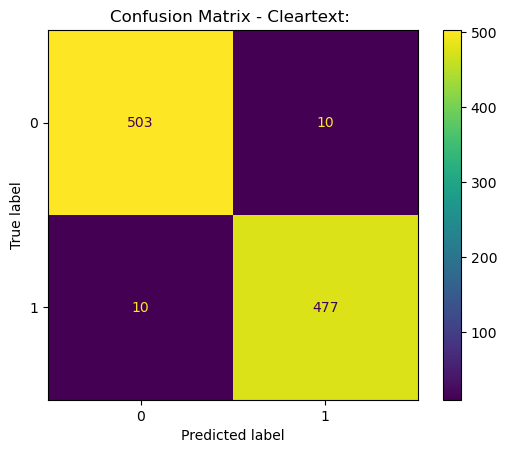

In [31]:
ld_clear_cm = metrics.confusion_matrix(ld_y_test, ld_y_pred_clear)
ld_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=ld_clear_cm)
ld_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [32]:
print("Classification Report - Cleartext: ")
print(classification_report(ld_y_test, ld_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       513
           1       0.98      0.98      0.98       487

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



FHE Execution and Evaluation

In [33]:
ld_fhe_prediction_start_time = time.time()

ld_y_pred_fhe = md_model.predict(ld_x_test, fhe="execute")

ld_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [34]:
ld_fhe_accuracy = accuracy_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_precision = precision_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_recall = recall_score (ld_y_test, ld_y_pred_fhe)
ld_fhe_f1 = f1_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_auc = roc_auc_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_prediction_elapsed_time = ld_fhe_prediction_end_time - ld_fhe_prediction_start_time

print("FHE Accuracy Score: ", ld_fhe_accuracy)
print("FHE Precision Score: ", ld_fhe_precision)
print("FHE Recall Score: ", ld_fhe_recall)
print("FHE F1 Score: ", ld_fhe_f1)
print("FHE AUC Score: ", ld_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {ld_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.399
FHE Precision Score:  0.39893617021276595
FHE Recall Score:  0.4620123203285421
FHE F1 Score:  0.42816365366317793
FHE AUC Score:  0.40059680343912485
Total time for FHE Execution and Evaluation: 17.92292 seconds


Confusion Matrix - FHE

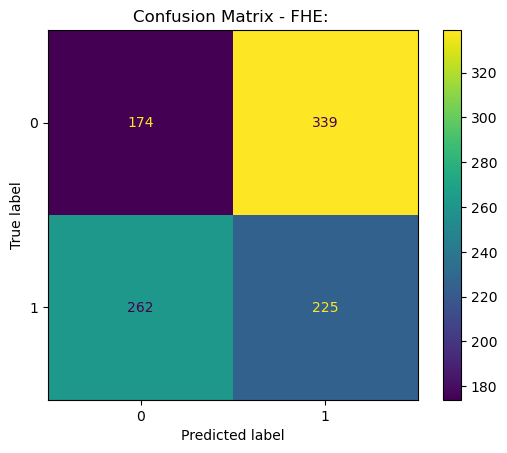

In [35]:
ld_fhe_cm = metrics.confusion_matrix(ld_y_test, ld_y_pred_fhe)
ld_fhe_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=ld_fhe_cm)
ld_fhe_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [36]:
print("Classification Report - FHE: ")
print(classification_report(ld_y_test, ld_y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.40      0.34      0.37       513
           1       0.40      0.46      0.43       487

    accuracy                           0.40      1000
   macro avg       0.40      0.40      0.40      1000
weighted avg       0.40      0.40      0.40      1000



Evaluation of LD Model

In [37]:
print("In clear  :", ld_y_pred_clear)
print("In FHE    :", ld_y_pred_fhe)
print(f"Similarity: {int((ld_y_pred_fhe == ld_y_pred_clear).mean()*100)}%")

ld_total_end_time = time.time()
ld_total_elapsed_time = ld_total_end_time - ld_total_start_time
print(f"Total time for MD to Run: {ld_total_elapsed_time:.5f} seconds")

In clear  : [0 1 1 0 1 0 0 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 0
 1 1 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1
 1 1 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 1 1 1 0 1 1
 1 0 0 1 0 0 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0
 1 1 0 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1
 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1
 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0
 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1
 0 0 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1
 0 1 1 1 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 1 0 1
 1 1 1 0 0 0 

# High Random Dataset - 100,000 samples

Makes Samples and Perform Train and Test Split

In [38]:
hd_x, hd_y = make_classification(n_samples=100000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", hd_x.min())
print("X Maximum: ", hd_x.max())

hd_x_train, hd_x_test, hd_y_train, hd_y_test = train_test_split(hd_x, hd_y, test_size=0.1, random_state=42)

X Minimum:  -6.3660521362614215
X Maximum:  5.954729534802098


Evaluate number of training and testing samples from train/test split

In [39]:
num_hd_x_training = len(hd_x_train)
num_hd_x_test = len(hd_x_test)
num_hd_y_training = len(hd_y_train)
num_hd_y_test = len(hd_y_test)

print("Number of x training: ", num_hd_x_training)
print("Number of x test: ", num_hd_x_test)
print("Number of y training: ", num_hd_y_training)
print("Number of y test: ", num_hd_y_test)

Number of x training:  90000
Number of x test:  10000
Number of y training:  90000
Number of y test:  10000


In [40]:
print("hd_x_train shape: ", hd_x_train.shape)
print("hd_x_test shape: ", hd_x_test.shape)
print("hd_y_train shape: ", hd_y_train.shape)
print("hd_y_test shape: ", hd_y_train.shape)

hd_x_train shape:  (90000, 30)
hd_x_test shape:  (10000, 30)
hd_y_train shape:  (90000,)
hd_y_test shape:  (90000,)


Initialise Model and Perform Fitting and Prediction

In [41]:
hd_total_start_time = time.time()

hd_model = LogisticRegression(n_bits=8)
hd_ml_start_time = time.time()

hd_model.fit(hd_x_train, hd_y_train)
hd_y_pred_clear = hd_model.predict(hd_x_test)
hd_model.compile(hd_x_train)

hd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpr42r2kab/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [42]:
hd_clear_accuracy = accuracy_score(hd_y_test, hd_y_pred_clear)
hd_clear_precision = precision_score(hd_y_test, hd_y_pred_clear)
hd_clear_recall = recall_score (hd_y_test, hd_y_pred_clear)
hd_clear_f1 = f1_score(hd_y_test, hd_y_pred_clear)
hd_clear_auc = roc_auc_score(hd_y_test, hd_y_pred_clear)
hd_ml_elapsed_time = hd_ml_end_time - hd_ml_start_time

print("Cleartext Accuracy Score: ", hd_clear_accuracy)
print("Cleartext Precision Score: ", hd_clear_precision)
print("Cleartext Recall Score: ", hd_clear_recall)
print("Cleartext F1 Score: ", hd_clear_f1)
print("Cleartext AUC Score: ", hd_clear_auc)
print(f"Time it took for ML to make predictions: {hd_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.9823
Cleartext Precision Score:  0.9798914136336215
Cleartext Recall Score:  0.9844444444444445
Cleartext F1 Score:  0.9821626524236622
Cleartext AUC Score:  0.9823212321232123
Time it took for ML to make predictions: 12.76664 seconds


Confusion Matrix - Cleartext

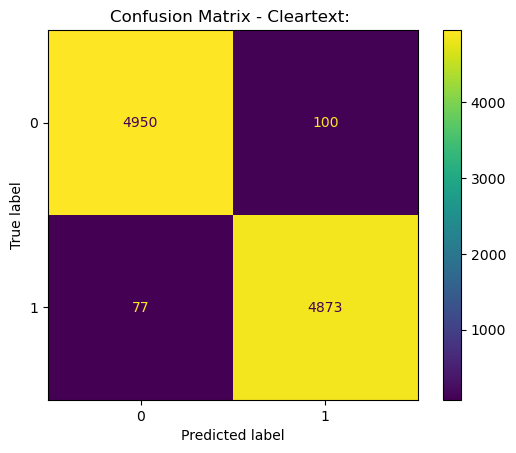

In [43]:
hd_clear_cm = metrics.confusion_matrix(hd_y_test, hd_y_pred_clear)
hd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=hd_clear_cm)
hd_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [44]:
print("Classification Report - Cleartext: ")
print(classification_report(hd_y_test, hd_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5050
           1       0.98      0.98      0.98      4950

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



FHE Execution and Evaluation

In [45]:
hd_fhe_prediction_start_time = time.time()

hd_y_pred_fhe = hd_model.predict(hd_x_test, fhe="execute")

hd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [46]:
hd_fhe_accuracy = accuracy_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_precision = precision_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_recall = recall_score (hd_y_test, hd_y_pred_fhe)
hd_fhe_f1 = f1_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_auc = roc_auc_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_prediction_elapsed_time = hd_fhe_prediction_end_time - hd_fhe_prediction_start_time

print("FHE Accuracy Score: ", hd_fhe_accuracy)
print("FHE Precision Score: ", hd_fhe_precision)
print("FHE Recall Score: ", hd_fhe_recall)
print("FHE F1 Score: ", hd_fhe_f1)
print("FHE AUC Score: ", hd_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {hd_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.9823
FHE Precision Score:  0.9798914136336215
FHE Recall Score:  0.9844444444444445
FHE F1 Score:  0.9821626524236622
FHE AUC Score:  0.9823212321232123
Total time for FHE Execution and Evaluation: 183.66368 seconds


Confusion Matrix - FHE

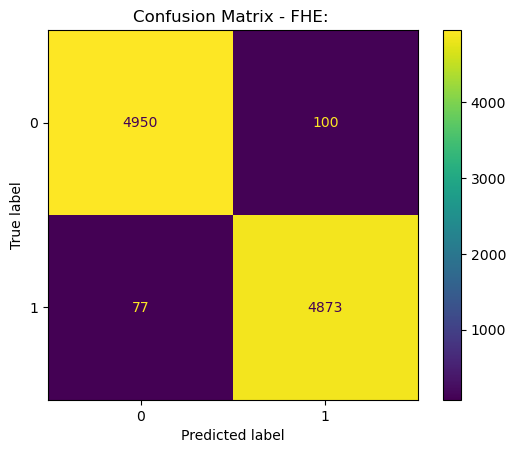

In [47]:
hd_fhe_cm = metrics.confusion_matrix(hd_y_test, hd_y_pred_fhe)
hd_fhe_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=hd_fhe_cm)
hd_fhe_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [48]:
print("Classification Report - FHE: ")
print(classification_report(hd_y_test, hd_y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5050
           1       0.98      0.98      0.98      4950

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Evaluation of HD Model

In [49]:
print("In clear  :", hd_y_pred_clear)
print("In FHE    :", hd_y_pred_fhe)
print(f"Similarity: {int((hd_y_pred_fhe == hd_y_pred_clear).mean()*100)}%")

hd_total_end_time = time.time()
hd_total_elapsed_time = hd_total_end_time - hd_total_start_time
print(f"Total time for HD to Run: {hd_total_elapsed_time:.5f} seconds")

In clear  : [0 0 1 ... 1 1 1]
In FHE    : [0 0 1 ... 1 1 1]
Similarity: 100%
Total time for HD to Run: 196.65475 seconds


# Mega Random Dataset - 1,000,000 samples

Makes Samples and Perform Train and Test Split

In [50]:
bd_x, bd_y = make_classification(n_samples=1000000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", bd_x.min())
print("X Maximum: ", bd_x.max())

bd_x_train, bd_x_test, bd_y_train, bd_y_test = train_test_split(bd_x, bd_y, test_size=0.1, random_state=42)

X Minimum:  -5.418165153290721
X Maximum:  6.633299322658303


Evalaute number of training and testing samples from train/test split

In [51]:
num_bd_x_training = len(bd_x_train)
num_bd_x_test = len(bd_x_test)
num_bd_y_training = len(bd_y_train)
num_bd_y_test = len(bd_y_test)

print("Number of x training: ", num_bd_x_training)
print("Number of x test: ", num_bd_x_test)
print("Number of y training: ", num_bd_y_training)
print("Number of y test: ", num_bd_y_test)

Number of x training:  900000
Number of x test:  100000
Number of y training:  900000
Number of y test:  100000


In [52]:
print("bd_x_train shape: ", bd_x_train.shape)
print("bd_x_test shape: ", bd_x_test.shape)
print("bd_y_train shape: ", bd_y_train.shape)
print("bd_y_test shape: ", bd_y_train.shape)

bd_x_train shape:  (900000, 30)
bd_x_test shape:  (100000, 30)
bd_y_train shape:  (900000,)
bd_y_test shape:  (900000,)


Initialise Model and Perform Fitting and Prediction

In [53]:
bd_total_start_time = time.time()

bd_model = LogisticRegression(n_bits=8)
bd_ml_start_time = time.time()

bd_model.fit(bd_x_train, bd_y_train)
bd_y_pred_clear = bd_model.predict(bd_x_test)
bd_model.compile(bd_x_train)

bd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmppq_eorfr/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [54]:
bd_clear_accuracy = accuracy_score(bd_y_test, bd_y_pred_clear)
bd_clear_precision = precision_score(bd_y_test, bd_y_pred_clear)
bd_clear_recall = recall_score (bd_y_test, bd_y_pred_clear)
bd_clear_f1 = f1_score(bd_y_test, bd_y_pred_clear)
bd_clear_auc = roc_auc_score(bd_y_test, bd_y_pred_clear)
bd_ml_elapsed_time = bd_ml_end_time - bd_ml_start_time

print("Cleartext Accuracy Score: ", bd_clear_accuracy)
print("Cleartext Precision Score: ", bd_clear_precision)
print("Cleartext Recall Score: ", bd_clear_recall)
print("Cleartext F1 Score: ", bd_clear_f1)
print("Cleartext AUC Score: ", bd_clear_auc)
print(f"Time it took for ML to make predictions: {bd_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.99407
Cleartext Precision Score:  0.9955110220440881
Cleartext Recall Score:  0.9926266360275752
Cleartext F1 Score:  0.9940667367051879
Cleartext AUC Score:  0.994071300197753
Time it took for ML to make predictions: 126.18063 seconds


Confusion Matrix - Cleartext

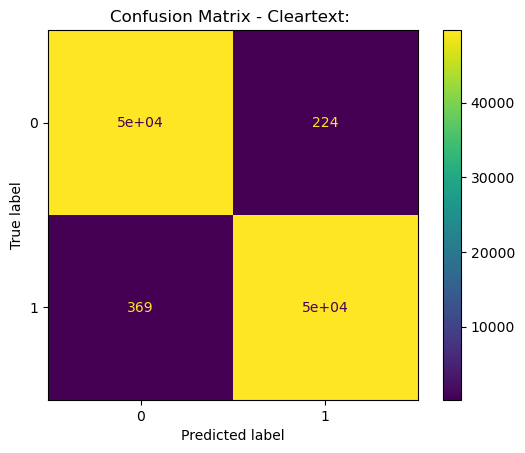

In [55]:
bd_clear_cm = metrics.confusion_matrix(bd_y_test, bd_y_pred_clear)
bd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=bd_clear_cm)
bd_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [56]:
print("Classification Report - Cleartext: ")
print(classification_report(bd_y_test, bd_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     49955
           1       1.00      0.99      0.99     50045

    accuracy                           0.99    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       0.99      0.99      0.99    100000



FHE Execution and Evaluation

In [57]:
bd_fhe_prediction_start_time = time.time()

bd_y_pred_fhe = bd_model.predict(bd_x_test, fhe="execute")

bd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [58]:
bd_fhe_accuracy = accuracy_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_precision = precision_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_recall = recall_score (bd_y_test, bd_y_pred_fhe)
bd_fhe_f1 = f1_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_auc = roc_auc_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_prediction_elapsed_time = bd_fhe_prediction_end_time - bd_fhe_prediction_start_time

print("FHE Accuracy Score: ", bd_fhe_accuracy)
print("FHE Precision Score: ", bd_fhe_precision)
print("FHE Recall Score: ", bd_fhe_recall)
print("FHE F1 Score: ", bd_fhe_f1)
print("FHE AUC Score: ", bd_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {bd_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.99407
FHE Precision Score:  0.9955110220440881
FHE Recall Score:  0.9926266360275752
FHE F1 Score:  0.9940667367051879
FHE AUC Score:  0.994071300197753
Total time for FHE Execution and Evaluation: 1756.40423 seconds


Confusion Matrix - FHE

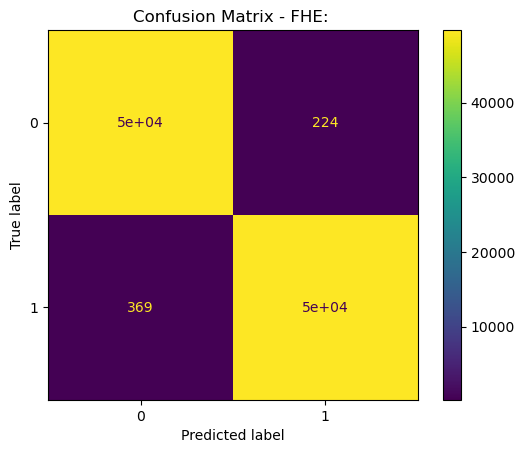

In [59]:
bd_fhe_cm = metrics.confusion_matrix(bd_y_test, bd_y_pred_fhe)
bd_fhe_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=bd_fhe_cm)
bd_fhe_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [60]:
print("Classification Report - FHE: ")
print(classification_report(bd_y_test, bd_y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     49955
           1       1.00      0.99      0.99     50045

    accuracy                           0.99    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       0.99      0.99      0.99    100000



Evaluation of BD Model

In [61]:
print("In clear  :", bd_y_pred_clear)
print("In FHE    :", bd_y_pred_fhe)
print(f"Similarity: {int((bd_y_pred_fhe == bd_y_pred_clear).mean()*100)}%")

bd_total_end_time = time.time()
bd_total_elapsed_time = bd_total_end_time - bd_total_start_time
print(f"Total time for BD to Run: {bd_total_elapsed_time:.5f} seconds")

In clear  : [0 1 1 ... 1 1 1]
In FHE    : [0 1 1 ... 1 1 1]
Similarity: 100%
Total time for BD to Run: 1883.17847 seconds


# Evaluation of all results

In [62]:
results = {
     '100 Dataset':["100", 
     f"{(sd_y_pred_fhe == sd_y_pred_clear).mean() * 100:.0f}%", 
     sd_ml_elapsed_time,
     sd_clear_accuracy,
     sd_clear_precision,
     sd_clear_recall,
     sd_clear_f1,
     sd_clear_auc,
     sd_fhe_prediction_elapsed_time,
     sd_fhe_accuracy,
     sd_fhe_precision,
     sd_fhe_recall,
     sd_fhe_f1,
     sd_fhe_auc, 
     sd_total_elapsed_time],
     '1000 Dataset':["1000", 
     f"{(md_y_pred_fhe == md_y_pred_clear).mean() * 100:.0f}%", 
     md_ml_elapsed_time,
     md_clear_accuracy,
     md_clear_precision,
     md_clear_recall,
     md_clear_f1,
     md_clear_auc,
     md_fhe_prediction_elapsed_time,
     md_fhe_accuracy,
     md_fhe_precision,
     md_fhe_recall,
     md_fhe_f1,
     md_fhe_auc, 
     md_total_elapsed_time],
     '10,000 Dataset':["10000", 
     f"{(ld_y_pred_fhe == ld_y_pred_clear).mean() * 100:.0f}%", 
     ld_ml_elapsed_time,
     ld_clear_accuracy,
     ld_clear_precision,
     ld_clear_recall,
     ld_clear_f1,
     ld_clear_auc,
     ld_fhe_prediction_elapsed_time,
     ld_fhe_accuracy,
     ld_fhe_precision,
     ld_fhe_recall,
     ld_fhe_f1,
     ld_fhe_auc, 
     ld_total_elapsed_time],
     '100,000 Dataset':["100000", 
     f"{(hd_y_pred_fhe == hd_y_pred_clear).mean() * 100:.0f}%", 
     hd_ml_elapsed_time,
     hd_clear_accuracy,
     hd_clear_precision,
     hd_clear_recall,
     hd_clear_f1,
     hd_clear_auc,
     hd_fhe_prediction_elapsed_time,
     hd_fhe_accuracy,
     hd_fhe_precision,
     hd_fhe_recall,
     hd_fhe_f1,
     hd_fhe_auc, 
     hd_total_elapsed_time],
     '1,000,000 Dataset':["1000000", 
     f"{(hd_y_pred_fhe == hd_y_pred_clear).mean() * 100:.0f}%", 
     bd_ml_elapsed_time,
     bd_clear_accuracy,
     bd_clear_precision,
     bd_clear_recall,
     bd_clear_f1,
     bd_clear_auc,
     bd_fhe_prediction_elapsed_time,
     bd_fhe_accuracy,
     bd_fhe_precision,
     bd_fhe_recall,
     bd_fhe_f1,
     bd_fhe_auc, 
     bd_total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time','CT Accuracy', 'CT Precision', 'CT Recall', 'CT F1', 
           'CT AUC', 'FHE Time', 'FHE Accuracy', 'FHE Precision', 'FHE Recall', 'FHE F1', 'FHE AUC', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results


,Samples,Similarity,ML Time,CT Accuracy,CT Precision,CT Recall,CT F1,CT AUC,FHE Time,FHE Accuracy,FHE Precision,FHE Recall,FHE F1,FHE AUC,Total Time
100 Dataset,100,100%,0.198748,1.0,1.0,1.0,1.0,1.0,0.55023,1.0,1.0,1.0,1.0,1.0,1.039226
1000 Dataset,1000,100%,0.370456,0.97,1.0,0.9375,0.967742,0.96875,2.044964,0.97,1.0,0.9375,0.967742,0.96875,2.611145
"10,000 Dataset",10000,40%,1.491905,0.98,0.979466,0.979466,0.979466,0.979986,17.922925,0.399,0.398936,0.462012,0.428164,0.400597,19.606231
"100,000 Dataset",100000,100%,12.766644,0.9823,0.979891,0.984444,0.982163,0.982321,183.663684,0.9823,0.979891,0.984444,0.982163,0.982321,196.654745
"1,000,000 Dataset",1000000,100%,126.180625,0.99407,0.995511,0.992627,0.994067,0.994071,1756.404226,0.99407,0.995511,0.992627,0.994067,0.994071,1883.17847
